In [ ]:
# Load curated metrics from PostgreSQL
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils.notebook_helpers import get_postgres_engine

engine, pg_conf = get_postgres_engine("../configs/database.yaml")

df = pd.read_sql_query("SELECT * FROM curated_device_metrics", engine)
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

print("Connected to PostgreSQL:", pg_conf["host"], pg_conf["db"])
print("rows:", len(df), "columns:", len(df.columns))
df.head()

rows: 10080 columns: 40


,device,timestamp,r_s,w_s,rmb_s,wmb_s,r_await,w_await,aqu_sz,util_pct,...,merge_rate_total,merge_efficiency,await_ratio,svctm_await_ratio,queue_efficiency,write_amplification,iowait_pressure,hour_of_day,day_of_week,workload_pattern
0,dm-0,2026-03-30 00:01:58.457739+00:00,130.543091,79.184408,9.858905,7.593411,0.515383,1.512394,1.228957,18.985405,...,15.071942,0.067046,2.934505,0.420782,170.654858,0.606577,0.000000,0,0,balanced
1,dm-0,2026-03-30 00:07:25.975778+00:00,140.798611,111.640416,13.975163,7.333685,0.722049,2.733421,0.337266,5.122736,...,19.275480,0.070940,3.785646,0.195221,748.487496,0.792909,0.132179,0,0,balanced
2,dm-0,2026-03-30 00:12:41.635044+00:00,125.286126,66.371400,12.555741,6.673198,0.747056,2.052067,0.148839,25.935530,...,11.395302,0.056120,2.746871,0.403519,1287.686269,0.529759,0.605503,0,0,balanced
3,dm-0,2026-03-30 00:17:16.872031+00:00,100.356193,75.783214,8.572476,6.661890,0.920823,0.937210,0.292099,26.257811,...,20.766181,0.105463,1.017796,0.467947,603.013560,0.755142,0.187236,0,0,balanced
4,dm-0,2026-03-30 00:22:38.881089+00:00,108.479764,117.221000,7.843162,6.857079,1.402010,1.604284,0.796995,16.542202,...,26.409877,0.104755,1.144274,0.231731,283.189648,1.080579,0.000000,0,0,balanced


In [15]:
df["device"].nunique()
df.shape
df["timestamp"].min(), df["timestamp"].max()

(Timestamp('2026-03-30 00:01:58.457739+0000', tz='UTC'),
 Timestamp('2026-04-05 23:57:49.449651+0000', tz='UTC'))

In [16]:
eda_cols = [
    "total_iops",
    "avg_latency_ms",
    "util_pct",
    "aqu_sz",
    "saturation_score",
    "merge_efficiency",
    "queue_efficiency",
    "iowait_pressure",
    "svctm_await_ratio",
    "write_amplification",
]
df[eda_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
total_iops,10080.0,508.351111,428.642377,18.221891,241.291514,400.387044,647.318815,7297.475831
avg_latency_ms,10080.0,52.568262,813.186919,0.196167,0.706744,1.394085,3.967148,65239.601770
util_pct,10080.0,42.857076,28.274637,0.000000,21.090033,37.241194,59.648479,100.000000
aqu_sz,10080.0,0.873684,1.622369,0.035151,0.254563,0.496670,1.006278,92.694137
saturation_score,10080.0,49.768636,145.600399,0.000000,5.878913,16.871256,49.832859,8789.858007
merge_efficiency,10080.0,0.071217,0.070355,0.000560,0.027023,0.045846,0.089651,0.593957
queue_efficiency,10080.0,1427.135519,1731.154938,4.121025,376.451986,778.814380,1576.174370,15197.334728
iowait_pressure,10080.0,3.869413,7.240641,0.000000,0.248185,1.029026,3.318325,60.531309
svctm_await_ratio,10080.0,0.990143,5.826704,0.000061,0.319367,0.385835,0.486084,233.129410
write_amplification,10080.0,0.991718,0.736957,0.070882,0.604988,0.827796,1.140411,19.841084


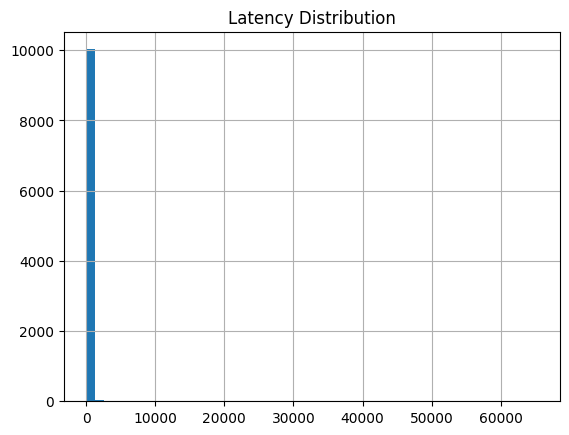

In [17]:
df["avg_latency_ms"].hist(bins=50)
plt.title("Latency Distribution")
plt.show()

In [18]:
quantiles = df[[
    "avg_latency_ms",
    "total_iops",
    "merge_efficiency",
    "queue_efficiency",
    "iowait_pressure",
]].quantile([0.5, 0.9, 0.95, 0.99])
quantiles

,avg_latency_ms,total_iops,merge_efficiency,queue_efficiency,iowait_pressure
0.50,1.394085,400.387044,0.045846,778.814380,1.029026
0.90,33.218134,992.667256,0.159999,3985.353134,11.731356
0.95,108.119421,1258.644263,0.225423,5504.070392,20.905876
0.99,773.454919,1799.626111,0.347457,7825.027381,35.034051


In [19]:
df.groupby("device")[[
    "total_iops",
    "avg_latency_ms",
    "util_pct",
    "merge_efficiency",
    "queue_efficiency",
    "iowait_pressure",
    "svctm_await_ratio",
    "write_amplification",
]].mean().round(4).sort_values("avg_latency_ms", ascending=False)

,total_iops,avg_latency_ms,util_pct,merge_efficiency,queue_efficiency,iowait_pressure,svctm_await_ratio,write_amplification
device,,,,,,,,
sdb,265.9801,255.6136,71.2685,0.1801,332.2044,13.2341,3.2806,1.7324
sda,454.4010,4.3804,50.8360,0.0405,1068.6607,3.3630,0.5063,1.0131
nvme0n1,723.1975,1.4349,39.6268,0.0157,4115.2363,1.2836,0.4055,0.5337
dm-0,372.4263,1.0954,24.9503,0.0815,516.8780,0.8789,0.4102,0.9181
nvme1n1,725.7505,0.3170,27.6038,0.0382,1102.6982,0.5874,0.3481,0.7613


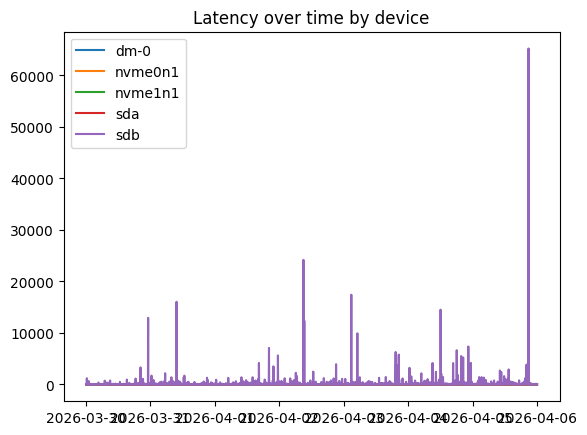

In [20]:
for device in df["device"].unique():
    subset = df[df["device"] == device]
    plt.plot(subset["timestamp"], subset["avg_latency_ms"], label=device)

plt.legend()
plt.title("Latency over time by device")
plt.show()

In [21]:
corr_cols = [
    "total_iops",
    "avg_latency_ms",
    "util_pct",
    "aqu_sz",
    "saturation_score",
    "merge_efficiency",
    "queue_efficiency",
    "iowait_pressure",
    "svctm_await_ratio",
]
df[corr_cols].corr()

,total_iops,avg_latency_ms,util_pct,aqu_sz,saturation_score,merge_efficiency,queue_efficiency,iowait_pressure,svctm_await_ratio
total_iops,1.000000,-0.034610,0.294240,0.043694,0.038721,-0.366484,0.397662,0.037058,-0.059643
avg_latency_ms,-0.034610,1.000000,0.064030,0.065324,0.074450,0.066338,-0.033870,0.079396,-0.009368
util_pct,0.294240,0.064030,1.000000,0.268712,0.374815,0.268358,-0.049227,0.743176,0.111637
aqu_sz,0.043694,0.065324,0.268712,1.000000,0.959117,0.282325,-0.262976,0.359014,0.028093
saturation_score,0.038721,0.074450,0.374815,0.959117,1.000000,0.259105,-0.181225,0.462528,0.040717
merge_efficiency,-0.366484,0.066338,0.268358,0.282325,0.259105,1.000000,-0.476232,0.408048,0.143388
queue_efficiency,0.397662,-0.033870,-0.049227,-0.262976,-0.181225,-0.476232,1.000000,-0.195678,-0.064745
iowait_pressure,0.037058,0.079396,0.743176,0.359014,0.462528,0.408048,-0.195678,1.000000,0.142197
svctm_await_ratio,-0.059643,-0.009368,0.111637,0.028093,0.040717,0.143388,-0.064745,0.142197,1.000000


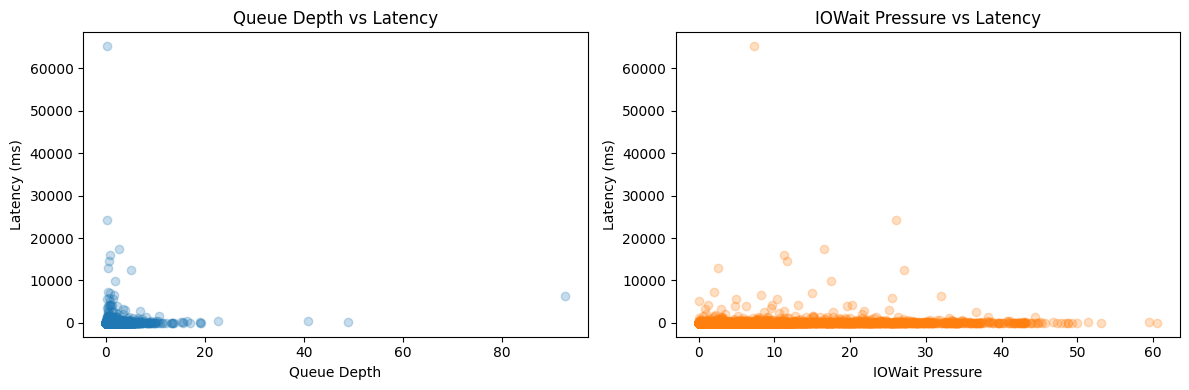

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(df["aqu_sz"], df["avg_latency_ms"], alpha=0.25)
axes[0].set_xlabel("Queue Depth")
axes[0].set_ylabel("Latency (ms)")
axes[0].set_title("Queue Depth vs Latency")

axes[1].scatter(df["iowait_pressure"], df["avg_latency_ms"], alpha=0.25, color="tab:orange")
axes[1].set_xlabel("IOWait Pressure")
axes[1].set_ylabel("Latency (ms)")
axes[1].set_title("IOWait Pressure vs Latency")

plt.tight_layout()
plt.show()

In [23]:
df["read_ratio"].describe()
df["write_ratio"].describe()

count    10080.000000
mean         0.461117
std          0.121434
min          0.066191
25%          0.376943
50%          0.452893
75%          0.532840
max          1.000000
Name: write_ratio, dtype: float64

In [24]:
df.groupby("hour_of_day")[[
    "total_iops",
    "avg_latency_ms",
    "iowait_pressure",
    "merge_efficiency",
    "queue_efficiency",
]].mean().round(3)

,total_iops,avg_latency_ms,iowait_pressure,merge_efficiency,queue_efficiency
hour_of_day,,,,,
0,258.817,34.796,0.931,0.077,1364.396
1,261.394,26.697,1.005,0.076,1470.528
2,264.307,60.822,1.014,0.077,1405.262
3,266.507,21.610,1.101,0.075,1310.909
4,290.840,41.721,1.354,0.072,1325.398
5,318.788,46.528,1.583,0.073,1376.571
6,361.702,31.410,2.141,0.075,1366.932
7,431.463,28.106,2.758,0.073,1421.501
8,566.864,78.070,3.950,0.072,1443.167


In [25]:
threshold = df["avg_latency_ms"].quantile(0.99)
high_latency = df[df["avg_latency_ms"] > threshold]
high_latency[[
    "device",
    "timestamp",
    "avg_latency_ms",
    "aqu_sz",
    "util_pct",
    "merge_efficiency",
    "queue_efficiency",
    "iowait_pressure",
    "workload_pattern",
]].head(20)

,device,timestamp,avg_latency_ms,aqu_sz,util_pct,merge_efficiency,queue_efficiency,iowait_pressure,workload_pattern
8067,sdb,2026-03-30 00:17:24.705995+00:00,1212.571308,1.613823,17.729574,0.271524,59.749832,0.000000,latency_sensitive
8171,sdb,2026-03-30 08:57:54.418433+00:00,778.544838,0.888247,45.790501,0.297566,192.329704,0.211201,latency_sensitive
8246,sdb,2026-03-30 15:11:57.028540+00:00,945.437346,7.234510,93.833251,0.297024,33.307091,16.881320,latency_sensitive
8285,sdb,2026-03-30 18:27:24.110607+00:00,1153.458591,0.518911,38.265047,0.379987,295.806640,3.131198,latency_sensitive
8307,sdb,2026-03-30 20:17:16.822649+00:00,3317.337239,3.463000,41.677362,0.346225,29.919361,2.983748,latency_sensitive
8318,sdb,2026-03-30 21:12:03.904634+00:00,1091.200582,6.519590,30.717178,0.074933,73.451224,15.269187,latency_sensitive
8341,sdb,2026-03-30 23:07:32.330347+00:00,12938.594640,0.515455,30.889336,0.207168,301.896491,2.627555,latency_sensitive
8356,sdb,2026-03-31 00:22:26.340567+00:00,1723.222366,0.671187,52.428275,0.284107,140.334025,2.228405,latency_sensitive
8365,sdb,2026-03-31 01:07:33.921983+00:00,863.463586,0.329887,40.892626,0.370846,163.929270,3.162041,latency_sensitive
8417,sdb,2026-03-31 05:27:49.459915+00:00,2194.065716,2.482844,43.007055,0.235796,52.659147,3.502219,latency_sensitive


In [26]:
df.sort_values("saturation_score", ascending=False).head(10)

,device,timestamp,r_s,w_s,rmb_s,wmb_s,r_await,w_await,aqu_sz,util_pct,...,merge_rate_total,merge_efficiency,await_ratio,svctm_await_ratio,queue_efficiency,write_amplification,iowait_pressure,hour_of_day,day_of_week,workload_pattern
9447,sdb,2026-04-03 19:17:46.883010+00:00,111.123978,270.870851,4.798152,5.059292,13.295251,8893.606319,92.694137,94.826472,...,73.820694,0.161953,668.931077,0.002107,4.121025,2.437555,32.035633,19,4,latency_sensitive
9442,sdb,2026-04-03 18:52:32.489110+00:00,109.780079,270.121964,5.528175,4.266892,395.666725,5.162302,48.831489,91.608985,...,68.584708,0.152925,0.013047,0.280288,7.779858,2.460574,19.899355,18,4,latency_sensitive
9448,sdb,2026-04-03 19:22:49.089391+00:00,165.355839,443.638094,4.748709,8.049471,254.881517,445.012596,40.754786,82.175214,...,66.648116,0.098644,1.745959,0.358826,14.942882,2.682930,21.411758,19,4,latency_sensitive
9449,sdb,2026-04-03 19:27:19.203201+00:00,154.745766,219.179170,4.695456,7.459320,52.415258,908.149025,22.584082,89.388497,...,43.486308,0.104181,17.326043,0.042565,16.557013,1.416382,27.435334,19,4,latency_sensitive
8489,sdb,2026-03-31 11:27:45.300536+00:00,118.230871,206.283221,6.077558,10.521247,47.888262,0.732566,19.138384,100.000000,...,113.791219,0.259616,0.015297,0.713925,16.956191,1.744749,23.205882,11,1,latency_sensitive
8802,sdb,2026-04-01 13:32:51.311608+00:00,126.666707,151.998512,5.509328,12.250974,90.255057,10.574720,19.062832,100.000000,...,117.711788,0.296969,0.117165,0.063796,14.618248,1.199988,32.196399,13,2,latency_sensitive
9069,sdb,2026-04-02 11:47:18.436236+00:00,105.627696,342.090346,8.126811,9.086996,26.247815,170.719030,18.980281,100.000000,...,118.757230,0.209642,6.504124,0.013174,23.588588,3.238643,29.573505,11,3,latency_sensitive
1940,dm-0,2026-04-05 17:42:00.013531+00:00,72.334245,99.940046,11.058352,9.061526,5.282614,14.899057,17.044566,100.000000,...,17.680917,0.093079,2.820395,0.167934,10.107286,1.381642,23.198580,17,6,latency_sensitive
9118,sdb,2026-04-02 15:52:07.069567+00:00,279.497627,175.394663,0.000000,7.426654,35.459968,263.226679,15.233759,100.000000,...,100.776279,0.181360,7.423207,0.718998,29.860804,0.627535,32.559586,15,3,latency_sensitive
9441,sdb,2026-04-03 18:47:05.818364+00:00,161.655766,331.767484,4.102721,8.890165,23.415310,247.832727,15.528148,90.753771,...,76.511941,0.134247,10.584217,0.112837,31.776054,2.052308,17.553255,18,4,latency_sensitive
